Description : Import des bibliothèques et chargement du dataset. Affichage des premières lignes et des statistiques descriptives.


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('outputs', exist_ok=True)

df = pd.read_csv('data/dataset.csv')

print("=== Aperçu ===")
print(df.head())
print(f"\nDimensions : {df.shape}")
print(f"\nValeurs manquantes : {df.isnull().sum().sum()}")
print(f"\nDoublons : {df.duplicated().sum()}")
print(f"\n{df.describe()}")

=== Aperçu ===
  client_id tranche_age                region abonnement_type  \
0      C001       70-79              Bretagne         Basique   
1      C002       60-69             Occitanie         Basique   
2      C003       70-79              Bretagne         Basique   
3      C004       70-79  Auvergne-Rhône-Alpes         Premium   
4      C005       70-79             Occitanie         Basique   

   anciennete_mois mobilite                            interets  \
0                7  Moyenne  accompagnement,santé,administratif   
1               11  Moyenne                             loisirs   
2               20  Moyenne               administratif,loisirs   
3               35   Faible                 santé,administratif   
4               39   Élevée                      accompagnement   

        categorie         prestation   prix  duree_min  niveau     mois  \
0           Santé      Suivi médical  56.07         90  Facile  2025-02   
1         Loisirs    Atelier créatif  28.

Description : Exploration rapide du dataset : résumé technique, statistiques descriptives des colonnes numériques et comptage des valeurs uniques par colonne catégorielle.


In [6]:
print("=== Exploration ===")
print(df.info())
print(df.describe())

print("\nValeurs uniques par colonne :")
for col in ['tranche_age', 'region', 'abonnement_type', 'mobilite', 'categorie', 'statut']:
    print(f"  {col} : {df[col].nunique()} valeurs uniques")

=== Exploration ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   client_id        500 non-null    object 
 1   tranche_age      500 non-null    object 
 2   region           500 non-null    object 
 3   abonnement_type  500 non-null    object 
 4   anciennete_mois  500 non-null    int64  
 5   mobilite         500 non-null    object 
 6   interets         500 non-null    object 
 7   categorie        500 non-null    object 
 8   prestation       500 non-null    object 
 9   prix             500 non-null    float64
 10  duree_min        500 non-null    int64  
 11  niveau           500 non-null    object 
 12  mois             500 non-null    object 
 13  inscription      500 non-null    int64  
 14  reinscription    500 non-null    int64  
 15  statut           500 non-null    object 
dtypes: float64(1), int64(4), object(11)
memory

Description : Dashboard Clients — 3 graphiques : clients par tranche d'âge, par région, et répartition des abonnements.


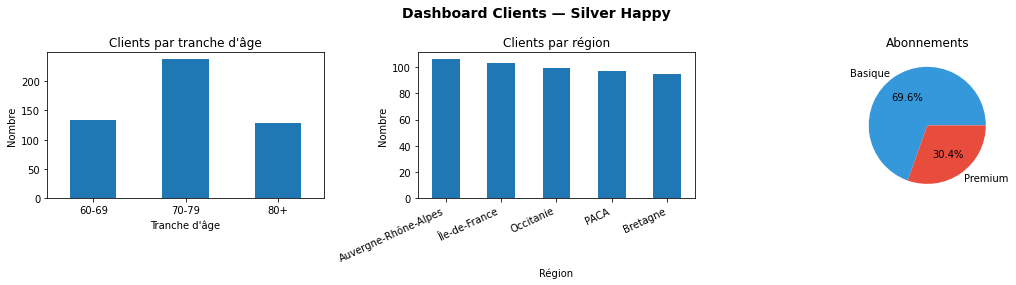

=== Dashboard Clients sauvegardé ===


In [7]:
plt.figure(figsize=(15, 4))
plt.suptitle('Dashboard Clients — Silver Happy', fontsize=14, fontweight='bold')

plt.subplot(1, 3, 1)
df['tranche_age'].value_counts().sort_index().plot(kind='bar')
plt.title("Clients par tranche d'âge")
plt.xlabel("Tranche d'âge")
plt.ylabel("Nombre")
plt.xticks(rotation=0)

plt.subplot(1, 3, 2)
df['region'].value_counts().plot(kind='bar')
plt.title('Clients par région')
plt.xlabel('Région')
plt.ylabel('Nombre')
plt.xticks(rotation=25, ha='right')

plt.subplot(1, 3, 3)
df['abonnement_type'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#3498db', '#e74c3c'])
plt.title('Abonnements')
plt.ylabel('')

plt.tight_layout()
plt.savefig('outputs/dashboard_clients.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== Dashboard Clients sauvegardé ===")

Description : Dashboard Prestations — 3 graphiques : inscriptions par catégorie, taux de réinscription par catégorie, et évolution des inscriptions par mois.

C:\Users\black\AppData\Local\Temp\ipykernel_5580\3778940429.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  taux = df.groupby('categorie').apply(lambda x: x['reinscription'].sum() / x['inscription'].sum())


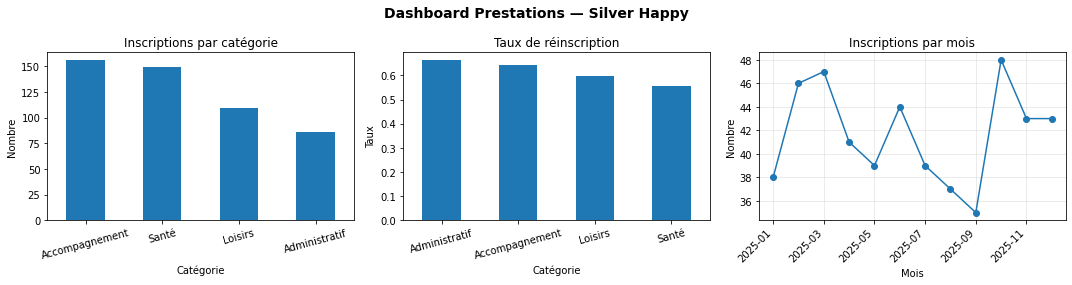

=== Dashboard Prestations sauvegardé ===


In [8]:
plt.figure(figsize=(15, 4))
plt.suptitle('Dashboard Prestations — Silver Happy', fontsize=14, fontweight='bold')

plt.subplot(1, 3, 1)
df.groupby('categorie')['inscription'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title('Inscriptions par catégorie')
plt.xlabel('Catégorie')
plt.ylabel('Nombre')
plt.xticks(rotation=15)

plt.subplot(1, 3, 2)
taux = df.groupby('categorie').apply(lambda x: x['reinscription'].sum() / x['inscription'].sum())
taux.sort_values(ascending=False).plot(kind='bar')
plt.title('Taux de réinscription')
plt.xlabel('Catégorie')
plt.ylabel('Taux')
plt.xticks(rotation=15)

plt.subplot(1, 3, 3)
df.groupby('mois')['inscription'].sum().sort_index().plot(kind='line', marker='o')
plt.title('Inscriptions par mois')
plt.xlabel('Mois')
plt.ylabel('Nombre')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/dashboard_prestations.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== Dashboard Prestations sauvegardé ===")